##Let us import, load and recreate all columns


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

pd.set_option('display.max_colwidth', 120)
sns.set_style('whitegrid')

# Load data
df = pd.read_csv("../data/clean/all_apps_clean.csv")
analyzer = SentimentIntensityAnalyzer()

# VADER functions
def get_vader_score(text):
    if pd.isna(text): return 0.0
    return analyzer.polarity_scores(str(text))['compound']

def vader_label(compound):
    if compound >= 0.05: return 'Positive'
    elif compound <= -0.05: return 'Negative'
    else: return 'Neutral'

def rating_label(rating):
    if rating >= 4: return 'Positive'
    elif rating <= 2: return 'Negative'
    else: return 'Neutral'

# Severity engine
severity_keywords = {
    5: ['locked out', 'account locked', 'account closed', 'money missing',
        'funds missing', 'stolen', 'fraud', 'scam', 'cannot access',
        'lost my money', 'money gone', 'unauthorized'],
    4: ['declined', 'card declined', 'transfer failed', 'verification failed',
        'failed', 'frozen', 'pending', 'verification', "can't send",
        "can't receive", 'not working', 'blocked'],
    3: ['customer service', 'support', 'refund', 'delay', 'late',
        'problem', 'issue', 'error', 'wrong', 'charge'],
    2: ['slow', 'bug', 'glitch', 'annoying', 'confusing', 'difficult'],
    1: ['minor', 'small', 'slight', 'okay', 'fine']
}

def compute_severity(text):
    if pd.isna(text): return 1
    text = str(text).lower()
    for level in [5, 4, 3, 2, 1]:
        for kw in severity_keywords[level]:
            if kw in text:
                return level
    return 1

severity_map = {1:'Low', 2:'Low-Moderate', 3:'Moderate', 4:'High', 5:'Critical'}

# Apply all columns
df['vader_compound']   = df['review_clean'].apply(get_vader_score)
df['vader_sentiment']  = df['vader_compound'].apply(vader_label)
df['rating_sentiment'] = df['rating'].apply(rating_label)
df['severity_score']   = df['review_clean'].apply(compute_severity)
df['severity_label']   = df['severity_score'].map(severity_map)

# Recreate hidden negatives
hidden_neg = df[
    (df['rating_sentiment'] == 'Negative') &
    (df['vader_sentiment']  != 'Negative')
].copy()

print(f"✅ df loaded: {df.shape}")
print(f"✅ Hidden negatives: {len(hidden_neg):,}")

✅ df loaded: (10386, 21)
✅ Hidden negatives: 1,307


**NOW LET US PREPARE THE TOPIC MODELLING CORPUS**

**We shall focus on moderate to critical hidden negatives only**

**These are the reviews with real businesss pain**

In [6]:
# Focus on moderate to critical hidden negatives only
# These are the reviews with real business pain
corpus_df = hidden_neg[hidden_neg['severity_score'] >= 3].copy()

# Drop any empty reviews
corpus_df = corpus_df.dropna(subset=['review_clean'])
corpus_df = corpus_df[corpus_df['review_clean'].str.strip() != '']

# Extract the text list BERTopic needs
docs = corpus_df['review_clean'].tolist()

print(f"✅ Corpus size for topic modeling: {len(docs):,} reviews")
print(f"   Severity breakdown:")
print(corpus_df['severity_label'].value_counts())
print(f"\nSample review:")
print(docs[0])

✅ Corpus size for topic modeling: 392 reviews
   Severity breakdown:
severity_label
Moderate    257
Critical     75
High         60
Name: count, dtype: int64

Sample review:
the support is not knowledgeable or clear untrained not personable


In [7]:
%pip install bertopic

^C
Note: you may need to restart the kernel to use updated packages.


**NOW LET US RUN BERTOPIC**

In [8]:
from bertopic import BERTopic

# Initialize and fit BERTopic
topic_model = BERTopic(
    language="english",
    calculate_probabilities=True,
    verbose=True,
    min_topic_size=10
)

topics, probs = topic_model.fit_transform(docs)

# Add topic assignments back to corpus_df
corpus_df = corpus_df.copy()
corpus_df['topic_id'] = topics

# Show topic info
topic_info = topic_model.get_topic_info()
print(f"\n✅ Topics found: {len(topic_info) - 1}")  # -1 excludes outlier topic
display(topic_info.head(15))

2026-05-28 21:04:03,551 - BERTopic - Embedding - Transforming documents to embeddings.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1133.93it/s]

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Batches: 100%|██████████| 13/13 [00:05<00:00,  2.19it/s]
2026-05-28 21:04:15,687 - BERTopic - Embedding - Completed ✓
2026-05-28 21:04:15,690 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-28 21:04:16,640 - BERTopic - Dimensionality - Completed ✓
2026-05-28 21:04:16,650 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-28 21:04:16,787 - BERTopic - Cluster - Completed ✓
2026-05-28 21:04:16,808 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-28 21:04:16,970 - BERTopic - Representation - Completed ✓



✅ Topics found: 7


,Topic,Count,Name,Representation,Representative_Docs
0,-1,91,-1_to_and_the_my,"[to, and, the, my, account, it, for, they, not, have]",[i messed up while making the account and it temporarily froze my account i contacted support told them the situatio...
1,0,87,0_app_the_to_and,"[app, the, to, and, it, my, this, is, cash, not]",[i cant get the app to load on my phone ive tried calling customer service theyre supposed to call me back its been ...
2,1,50,1_paypal_and_to_my,"[paypal, and, to, my, the, for, it, they, was, account]",[i tried to use it after years of inactivity because my daughters new dance class only uses paypal for some ungodly ...
3,2,45,2_venmo_to_the_and,"[venmo, to, the, and, of, it, is, card, my, money]",[ive always used venmo the straightforward way paying people directly who also had a venmo account recently they pro...
4,3,39,3_to_support_customer_is,"[to, support, customer, is, the, service, chat, ai, and, you]",[i got scammed out of some money sent to my daughter inlaw i tapped on her name and sent her the but it came back as...
5,4,32,4_chime_and_to_my,"[chime, and, to, my, the, have, they, me, now, it]",[so everything was great until they started requesting my check stubs and asking me why i have money in and out of m...
6,5,25,5_they_card_credit_the,"[they, card, credit, the, to, and, its, my, of, you]",[if an order is ever canceled they will hold on to your funds for up to a month while their customer service team ex...
7,6,23,6_scammers_to_the_scam,"[scammers, to, the, scam, and, they, money, fraud, back, scammed]",[pray to whatever you believe in that you dont need scam protection because as it turns out there isnt any i opened ...


**Now let us assigne the names and create the Executive Dashboard**

In [9]:
# Create a dictionary mapping the topic IDs to meaningful labels
topic_labels = {
    -1: "Miscellaneous/Noise",
    0: "App Performance & Support",
    1: "PayPal Account Disputes",
    2: "Venmo Transaction Friction",
    3: "Chime Banking System Issues",
    4: "AI Support & Bot Frustration",
    5: "Fund Holds & Card Issues",
    6: "Fraud & Scam Protection Failures"
}

corpus_df['topic_name'] = corpus_df['topic_id'].map(topic_labels)

# Show the new breakdown
print("Top Complaint Themes (Hidden Negatives):")
print(corpus_df['topic_name'].value_counts())

Top Complaint Themes (Hidden Negatives):
topic_name
Miscellaneous/Noise                 91
App Performance & Support           87
PayPal Account Disputes             50
Venmo Transaction Friction          45
Chime Banking System Issues         39
AI Support & Bot Frustration        32
Fund Holds & Card Issues            25
Fraud & Scam Protection Failures    23
Name: count, dtype: int64


Now we look at the **Distributed Pain Complaint themes by app**

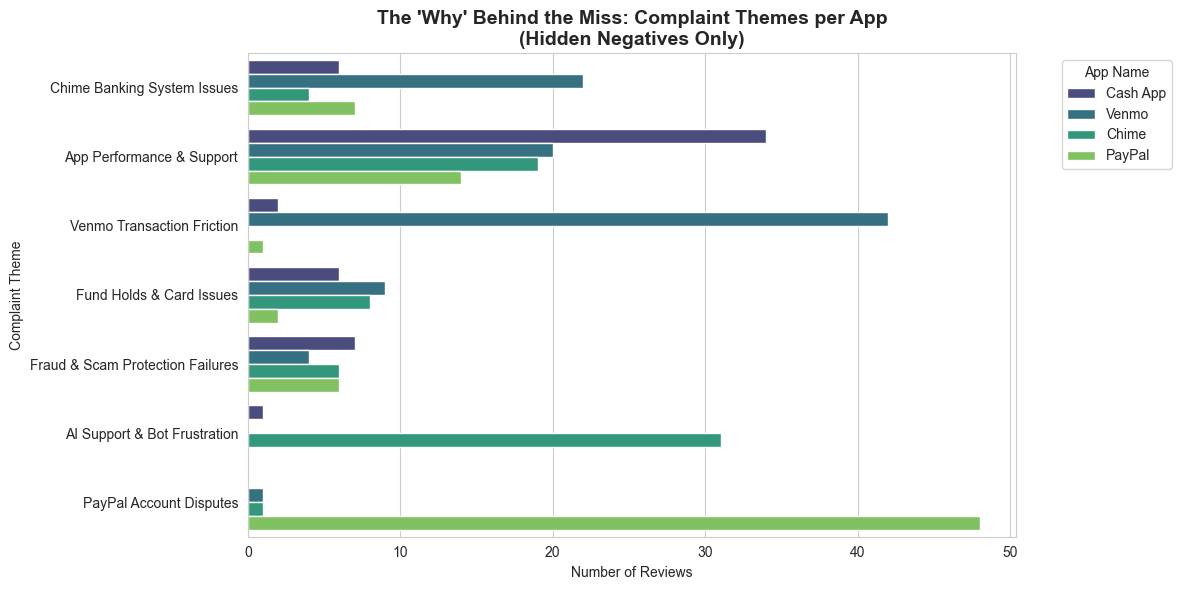

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# We exclude Topic -1 (Noise) for the final presentation
viz_df = corpus_df[corpus_df['topic_id'] != -1]

plt.figure(figsize=(12, 6))
sns.countplot(data=viz_df, y='topic_name', hue='app_name', palette='viridis')

plt.title("The 'Why' Behind the Miss: Complaint Themes per App\n(Hidden Negatives Only)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Reviews")
plt.ylabel("Complaint Theme")
plt.legend(title="App Name", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("topics_by_app.png", dpi=150, bbox_inches='tight')
plt.show()

Now let us **connect Topics to Severity**

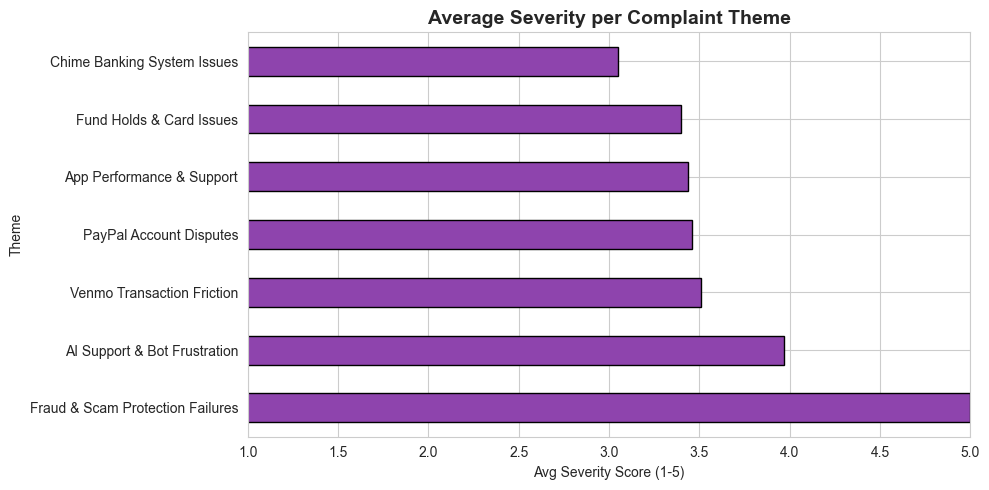

In [11]:
# Calculate average severity per topic
topic_severity = viz_df.groupby('topic_name')['severity_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
topic_severity.plot(kind='barh', color='#8e44ad', edgecolor='black')

plt.title("Average Severity per Complaint Theme", fontsize=14, fontweight='bold')
plt.xlabel("Avg Severity Score (1-5)")
plt.ylabel("Theme")
plt.xlim(1, 5) # Scale to show full range
plt.tight_layout()
plt.savefig("topic_severity.png", dpi=150, bbox_inches='tight')
plt.show()